In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Flame_fun import process_flame_dataset

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, RBF
from sklearn.gaussian_process.kernels import WhiteKernel
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.cross_decomposition import PLSRegression

from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import LeaveOneOut

import warnings

In [2]:
# IMPORT DES DONNÉES + PRÉTRAITEMENT

# Chemin du fichier CSV contenant les variables d'entrée
csv_path = "Data4ML.csv"

# Lecture du fichier CSV
df = pd.read_csv(csv_path, sep=";")

# Dossier contenant les images de flamme
base_image_folder = r".\data"

# Sélection des 22 premières colonnes comme variables explicatives
X_df = df.iloc[:, :22]

# Transformation de PhiInt :
# on applique ici un changement de variable pour ramener PhiInt
# dans une forme normalisée : PhiInt / (1 + PhiInt)
X_df.PhiInt = X_df.PhiInt / (1 + X_df.PhiInt)

# Calcul de l'écart-type de chaque variable
stds = X_df.std()

# Détection des variables quasi constantes
# (elles n'apportent pratiquement pas d'information au modèle)
variables_cst = stds[stds < 1e-5].index.tolist()

# Suppression des variables quasi constantes
X_df = X_df.drop(columns=variables_cst)

# Suppression manuelle de variables fortement corrélées à PhiInt
# pour limiter la redondance d'information
variables_corr = ['Xst', 'Zst', 'rho1', 'MW1', 'm1', 'm2']
X_df = X_df.drop(columns=variables_corr)

# Chargement des images de flamme, de l'image moyenne et de la liste des flame lengths
imgs, mean_flame_image, FL_list = process_flame_dataset(csv_path, base_image_folder, 25)

# Conversion de la liste des longueurs de flamme en tableau colonne
FL_array = np.array(FL_list).reshape(-1, 1)

# Conversion du DataFrame en matrice numpy
X = X_df.values

# Standardisation globale des variables d'entrée :
# centrage-réduction pour donner la même échelle à toutes les variables
scaler_X_global = StandardScaler()
X_scaled = scaler_X_global.fit_transform(X)

# Nombre final de variables explicatives conservées
n_features = X.shape[1]


In [3]:
# PLS GLOBAL
# Cette étape sert à projeter les images sur un espace latent réduit. Les scores PLS obtenus seront ensuite modélisés indépendamment.
# Ici, le PLS n'est pas utilisé directement pour prédire, mais pour construire les variables latentes (modes).
n_modes = 8
pls_global = PLSRegression(n_components=n_modes) 
pls_global.fit(imgs,FL_array) 
y_global = pls_global.x_scores_ 


MODE PLS 1 / 8


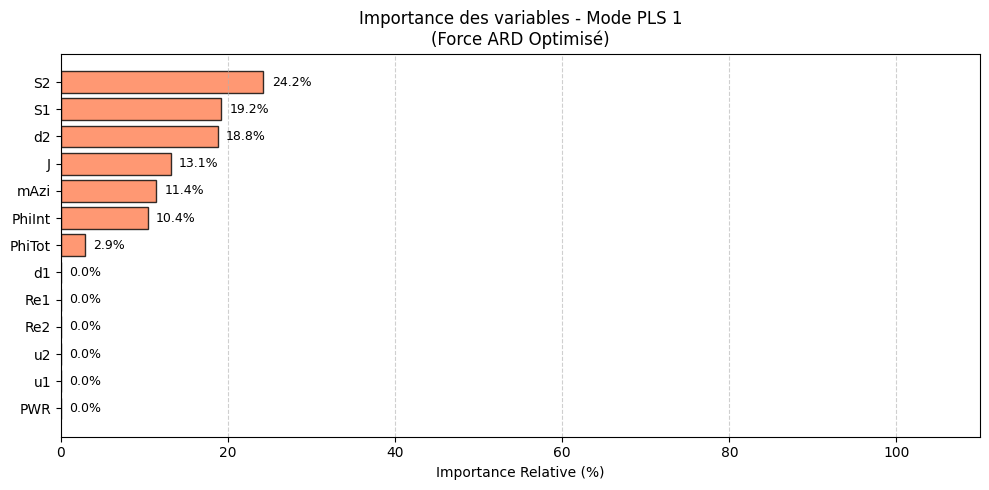


MODE PLS 2 / 8


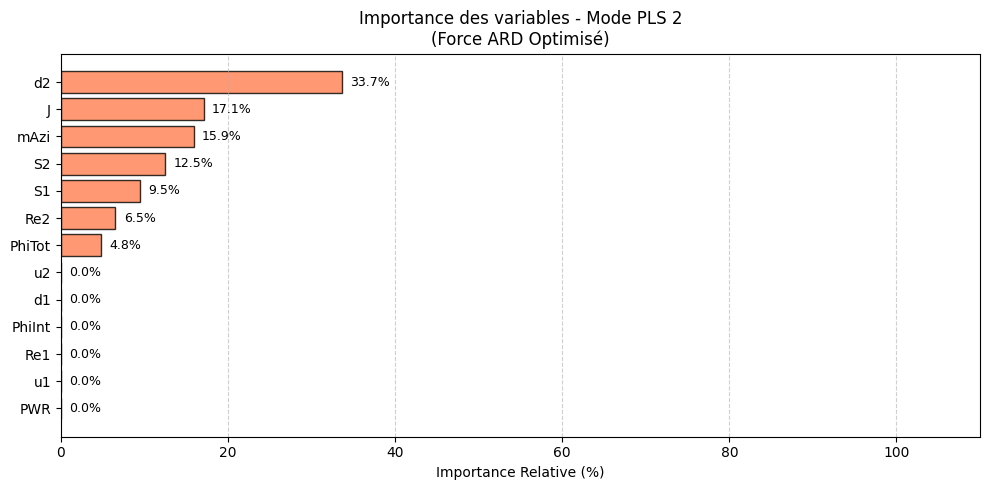


MODE PLS 3 / 8


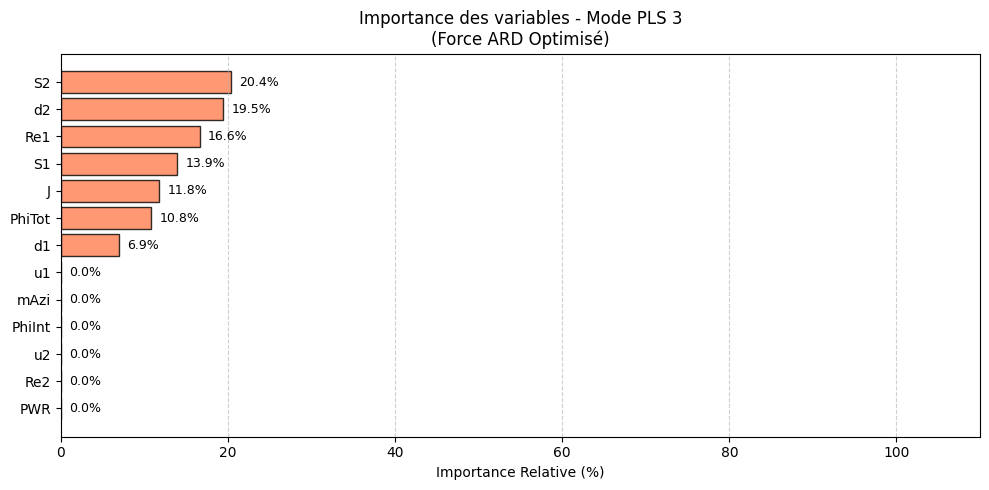


MODE PLS 4 / 8


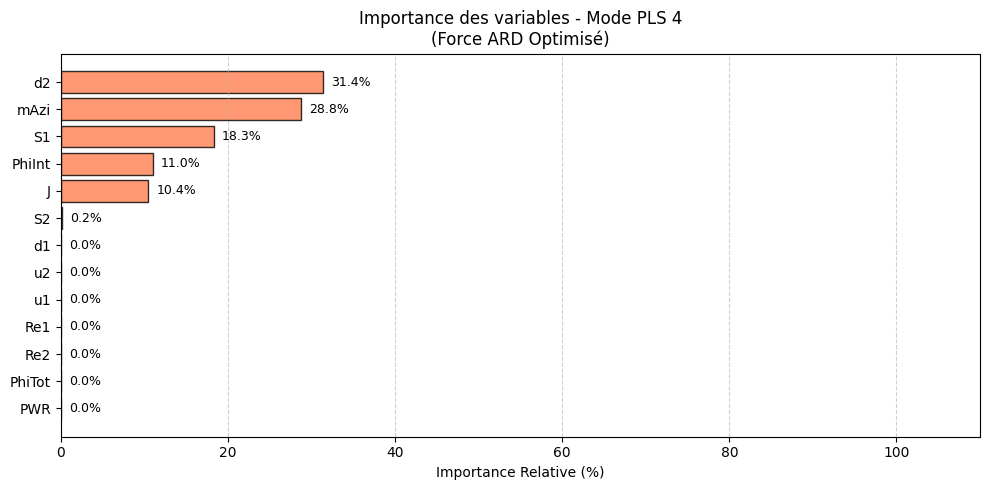


MODE PLS 5 / 8


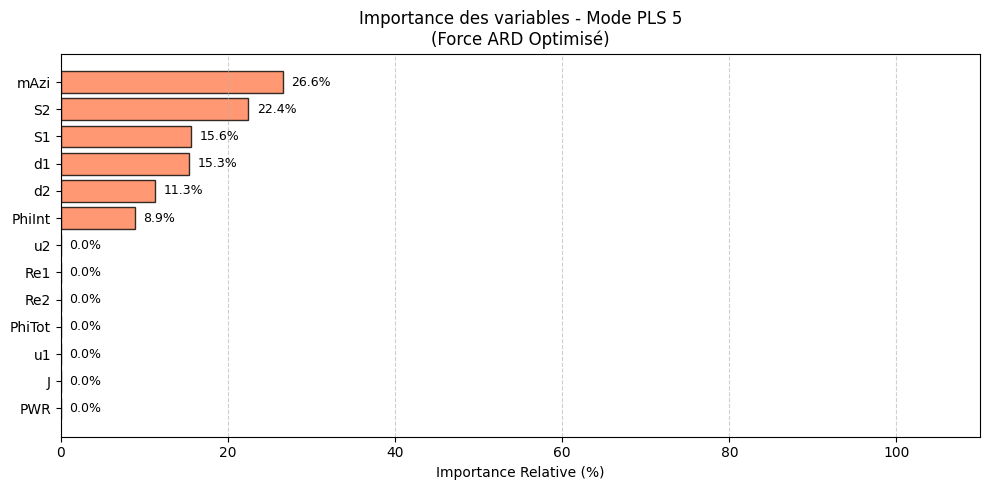


MODE PLS 6 / 8


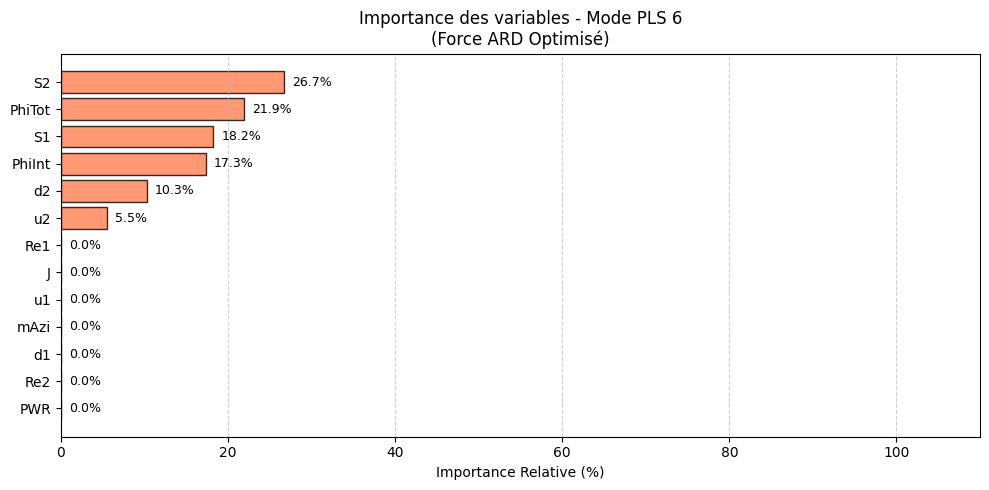


MODE PLS 7 / 8


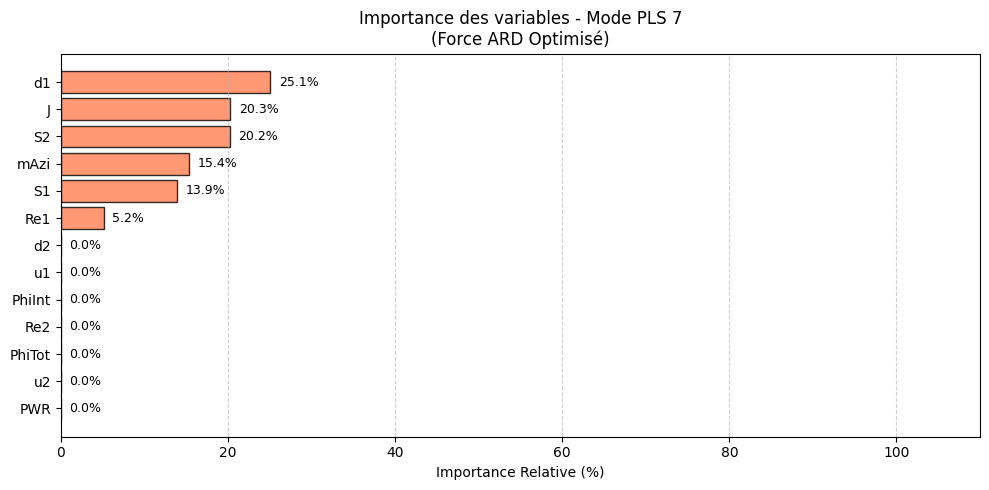


MODE PLS 8 / 8


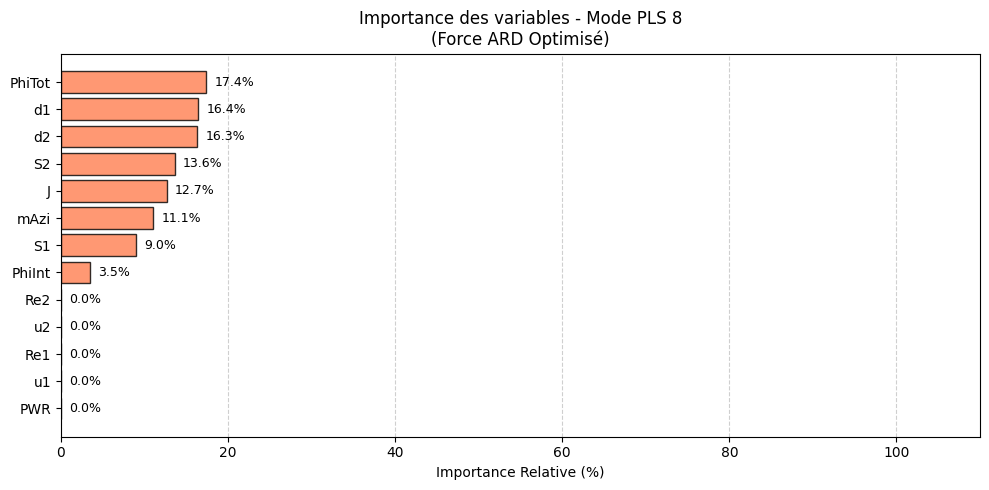

In [4]:
#  ÉTUDE DES VARIABLES IMPORTANTES PAR MODE PLS À L'AIDE D'UN GPR AVEC NOYAU ARD
# L'idée ici est d'entraîner un Gaussian Process Regressor sur chaque mode PLS séparément, avec un noyau anisotrope (ARD).
# Les longueurs caractéristiques apprises par le noyau permettent d'évaluer l'importance relative de chaque variable d'entrée.

warnings.filterwarnings("ignore")

ard_length = np.ones(n_features) # GPR anisotrope 

param_grid_features = {
    "kernel": [
        # --- GPR anisotropique pour l'étude des longueurs caractéristiques 
        C(1.0) * Matern(length_scale=ard_length, nu=1.5),
        C(1.0) * Matern(length_scale=ard_length, nu=2.5),
        C(1.0) * RBF(length_scale=ard_length),
    ],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2] 
}

gpr = GaussianProcessRegressor(n_restarts_optimizer=5, normalize_y=True)

# Recherche des meilleurs hyperparamètres par validation croisée
grid_search_features = GridSearchCV(estimator=gpr, 
                                  param_grid=param_grid_features, 
                                  cv=5, 
                                  scoring='neg_root_mean_squared_error', 
                                  n_jobs=-1, 
                                  verbose=0)

n_modes = 8
feature_names = X_df.columns 

# Liste qui stockera le meilleur noyau pour chaque mode
List_kernel_opt = []
importance_matrix = np.zeros((n_features, n_modes))

# Boucle sur les différents modes PLS
for k in range(n_modes):
    print(f"\n=========================================")
    print(f"MODE PLS {k+1} / {n_modes}")
    print(f"=========================================")
    
    # Extraction de la cible correspondant au mode k
    y_global_k = y_global[:,k]
    
    # Recherche du meilleur GPR pour ce mode
    grid_search_features.fit(X_scaled,y_global_k)
    kernel_opt_k = grid_search_features.best_estimator_.kernel_
    List_kernel_opt.append(kernel_opt_k) 
    
    # Extraction des longueurs caractéristiques du noyau
    ls = kernel_opt_k.k2.length_scale
    
    # Conversion des longueurs caractéristiques en score d'importance
    importance = 1.0 / (1.0 + ls)
    importance_norm = 100 * (importance / np.sum(importance))
    importance_matrix[:, k] = importance_norm
    
    sorted_idx = np.argsort(importance_norm)
    sorted_features = feature_names[sorted_idx]
    sorted_importance = importance_norm[sorted_idx]
    
    plt.figure(figsize=(10, 5))
    plt.barh(sorted_features, sorted_importance, color='coral', edgecolor='black', alpha=0.8)
    plt.xlabel("Importance Relative (%)")
    plt.title(f"Importance des variables - Mode PLS {k+1}\n(Force ARD Optimisé)")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    for index, value in enumerate(sorted_importance):
        plt.text(value + 1, index, f"{value:.1f}%", va='center', fontsize=9)
        
    plt.xlim(0, 110)
    plt.tight_layout()
    plt.show()


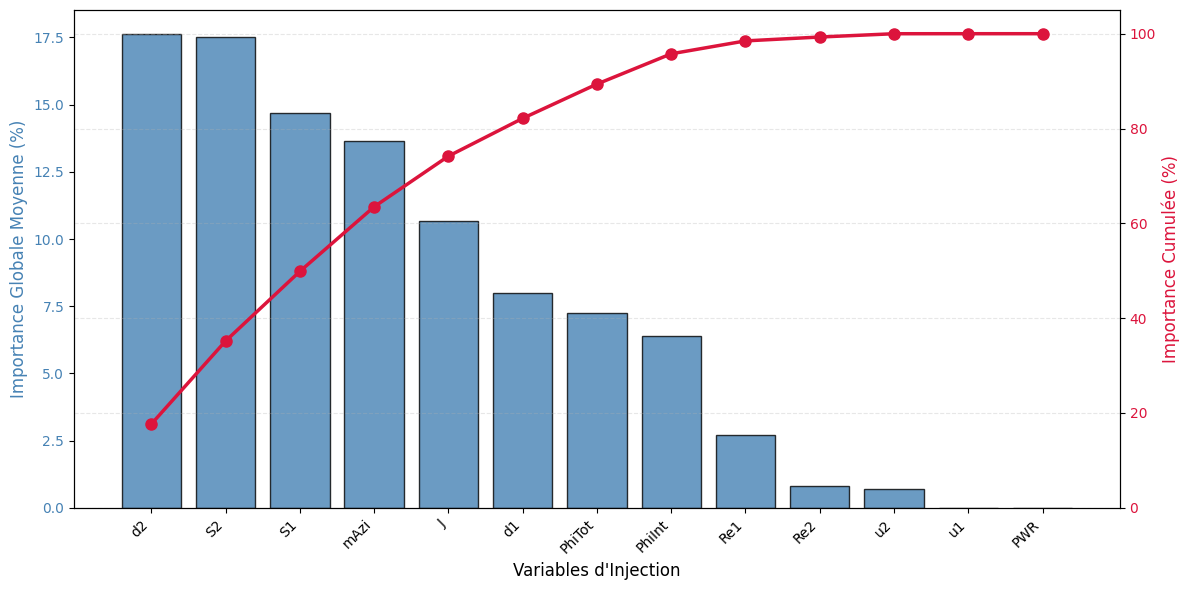

In [5]:
# IMPORTANCE GLOBALE MOYENNE DES VARIABLES
# Cette partie vise à moyenner les importances des variables sur l'ensemble des modes PLS, puis à tracer un diagramme de Pareto.

# Moyenne des importances sur tous les modes
global_importance = np.mean(importance_matrix, axis=1)

# Tri décroissant des variables selon leur importance moyenne
sorted_idx = np.argsort(global_importance)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importance = global_importance[sorted_idx]

# Calcul de l'importance cumulée
cumulative_importance = np.cumsum(sorted_importance)

# GÉNÉRATION DU DIAGRAMME DE PARETO
fig, ax1 = plt.subplots(figsize=(12, 6))

# Diagramme en barres : importance moyenne de chaque variable
bars = ax1.bar(sorted_features, sorted_importance, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_ylabel("Importance Globale Moyenne (%)", fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel("Variables d'Injection", fontsize=12)
ax1.set_xticklabels(sorted_features, rotation=45, ha='right')

# Deuxième axe Y pour afficher l'importance cumulée
ax2 = ax1.twinx()
line = ax2.plot(sorted_features, cumulative_importance, color='crimson', marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel("Importance Cumulée (%)", fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 105)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# RÉSULTATS DE LA PREMIÈRE ÉTUDE :
# D'après les graphes précédents, les variables : ['u1', 'u2', 'Re1', 'PWR', 'Re2'] apparaissent comme peu influentes, au moins sur les 5 premiers modes PLS.
# On choisit donc de les retirer pour construire un nouveau jeu de données plus compact, potentiellement plus robuste et plus facile à interpréter.

variables_uns = ['Re1','Re2','u1','u2','PWR']
X_df1 = X_df.drop(columns=variables_uns)
X1 = X_df1.values
scaler_X1_global = StandardScaler()
X1_scaled = scaler_X1_global.fit_transform(X1) 
n_features1 = X1.shape[1]

In [7]:
# GRID SEARCH : CHOIX DU MEILLEUR GPR POUR CHAQUE COEFFICIENT MODAL
# Cette étape consiste à identifier, pour chaque mode PLS, la meilleure configuration de Gaussian Process Regressor (GPR).
# On compare plusieurs noyaux :
# - isotropes : une seule longueur caractéristique pour toutes les variables
# - anisotropes (ARD) : une longueur caractéristique par variable
# On teste aussi plusieurs niveaux de régularisation via alpha, ainsi que l'ajout éventuel d'un WhiteKernel pour modéliser du bruit.

warnings.filterwarnings("ignore")

iso_length = 1.0 # GPR isotrope
ard_length = np.ones(n_features1) # GPR anisotrope 

# Grille des hyperparamètres à tester dans la recherche par validation croisée
param_grid_global = {
    "kernel": [
        # --- GPR isotropre 
        C(1.0) * Matern(length_scale=iso_length, nu=1.5), # Matern 1.5 : Souple
        C(1.0) * Matern(length_scale=iso_length, nu=2.5), # Matern 2.5 : Intermédiaire 
        C(1.0) * RBF(length_scale=iso_length), # RBF : Très lisse 
        C(1.0) * Matern(length_scale=iso_length, nu=1.5) + WhiteKernel(noise_level=1e-3), # Optimisation du bruit 
        # --- GPR anisotropique 
        C(1.0) * Matern(length_scale=ard_length, nu=1.5),
        C(1.0) * Matern(length_scale=ard_length, nu=2.5),
        C(1.0) * RBF(length_scale=ard_length),
        C(1.0) * Matern(length_scale=ard_length, nu=1.5) + WhiteKernel(noise_level=1e-3) # 1e-2 peut être
    ],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2] 
}

gpr = GaussianProcessRegressor(n_restarts_optimizer=5, normalize_y=True)
grid_search_global = GridSearchCV(estimator=gpr, 
                                  param_grid=param_grid_global, 
                                  cv=5, 
                                  scoring='neg_root_mean_squared_error', 
                                  n_jobs=-1, 
                                  verbose=0)

In [8]:
# DEUXIÈME ÉTUDE : MEILLEUR NOYAU ET MEILLEUR BRUIT POUR CHAQUE MODE PLS
# Pour chacun des 8 modes PLS, on ajuste un GPR via GridSearchCV et on affiche les 3 meilleures configurations obtenues
# selon la RMSE en validation croisée 5-fold.
n_modes = 8

for k in range(n_modes):
    print(f"\n=========================================")
    print(f"MODE PLS {k+1} / {n_modes}")
    print(f"=========================================")
    
    # Cible associée au mode PLS k
    y_global_k = y_global[:,k]
    
    # Recherche du meilleur modèle GPR pour ce mode
    grid_search_global.fit(X1_scaled,y_global_k)
    results_k = pd.DataFrame(grid_search_global.cv_results_)
    
    # Sélection des 3 meilleures configurations
    top_results = results_k.sort_values(by='mean_test_score', ascending=False).head(3)
    
    # Affichage des meilleurs résultats
    for i, (index, row) in enumerate(top_results.iterrows()):
        kernel_str = str(row['param_kernel']).replace('\n', '')
        alpha_val = row['param_alpha']
        r2_mean = row['mean_test_score']
        r2_std = row['std_test_score']
        
        k_type = "ARD (Multiple)" if "length_scale=[1" in kernel_str else "Isotrope (Unique)"
        k_base = "Matern 1.5" if "nu=1.5" in kernel_str else "Matern 2.5" if "nu=2.5" in kernel_str else "RBF"
        if "WhiteKernel" in kernel_str: k_base += " + WhiteKernel"
            
        print(f"Rang {i+1} : RMSE CV = {r2_mean:.3f} (±{r2_std:.3f})")
        print(f"  -> Type  : {k_base} | {k_type}")
        print(f"  -> Alpha : {alpha_val}")


MODE PLS 1 / 8
Rang 1 : RMSE CV = -6.640 (±2.565)
  -> Type  : Matern 1.5 + WhiteKernel | Isotrope (Unique)
  -> Alpha : 0.01
Rang 2 : RMSE CV = -6.641 (±2.565)
  -> Type  : Matern 1.5 | Isotrope (Unique)
  -> Alpha : 0.01
Rang 3 : RMSE CV = -7.618 (±2.671)
  -> Type  : Matern 1.5 + WhiteKernel | Isotrope (Unique)
  -> Alpha : 0.001

MODE PLS 2 / 8
Rang 1 : RMSE CV = -6.810 (±2.845)
  -> Type  : Matern 1.5 + WhiteKernel | ARD (Multiple)
  -> Alpha : 0.01
Rang 2 : RMSE CV = -6.810 (±2.845)
  -> Type  : Matern 1.5 | ARD (Multiple)
  -> Alpha : 0.01
Rang 3 : RMSE CV = -6.890 (±2.612)
  -> Type  : Matern 1.5 + WhiteKernel | ARD (Multiple)
  -> Alpha : 1e-05

MODE PLS 3 / 8
Rang 1 : RMSE CV = -8.551 (±3.732)
  -> Type  : Matern 1.5 + WhiteKernel | Isotrope (Unique)
  -> Alpha : 0.01
Rang 2 : RMSE CV = -8.551 (±3.732)
  -> Type  : Matern 1.5 | Isotrope (Unique)
  -> Alpha : 0.01
Rang 3 : RMSE CV = -8.694 (±3.750)
  -> Type  : Matern 1.5 + WhiteKernel | Isotrope (Unique)
  -> Alpha : 0.001



In [9]:
## Résultats de la deuxième étude : on stocke les meilleurs hyperparamètres trouvés.

Best_GPR_global = [
        # Mode 1 : Matern 1.5 | Iso | Alpha 0.01
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=1.0, nu=1.5), alpha=0.01, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 2 : Matern 1.5 | ARD | Alpha 0.01
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=ard_length, nu=1.5), alpha=0.01, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 3 : Matern 1.5 | Iso | Alpha 0.01
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=1.0, nu=1.5), alpha=0.01, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 4 : Matern 2.5 | ARD | Alpha 1e-5
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=ard_length, nu=2.5), alpha=1e-05, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 5 : Matern 2.5 | ARD | Alpha 0.0001
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=ard_length, nu=2.5), alpha=1e-05, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 6 : Matern 1.5 | Iso | Alpha 0.01
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=1.0, nu=1.5), alpha=0.01, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 7 : Matern 2.5 | ARD | Alpha 0.0001
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=ard_length, nu=1.5), alpha=0.0001, n_restarts_optimizer=3, normalize_y=True),
        
        # Mode 8 : Matern 1.5 | Iso | Alpha 0.01
        GaussianProcessRegressor(kernel=C(1.0) * Matern(length_scale=1.0, nu=1.5), alpha=0.01, n_restarts_optimizer=3, normalize_y=True),
        ]

--- Lancement du Shuffle Split (n=50) ---
Traitement du split 1 / 50 ...
Traitement du split 5 / 50 ...
Traitement du split 10 / 50 ...
Traitement du split 15 / 50 ...
Traitement du split 20 / 50 ...
Traitement du split 25 / 50 ...
Traitement du split 30 / 50 ...
Traitement du split 35 / 50 ...
Traitement du split 40 / 50 ...
Traitement du split 45 / 50 ...
Traitement du split 50 / 50 ...

=== RÉSULTATS FINAUX (Shuffle Split n=50) ===
R² global                 : 0.895
RMSE global               : 12.300
Prédictions dans le CI 95% : 85.4 %
Largeur moyenne du CI 95%  : 41.560


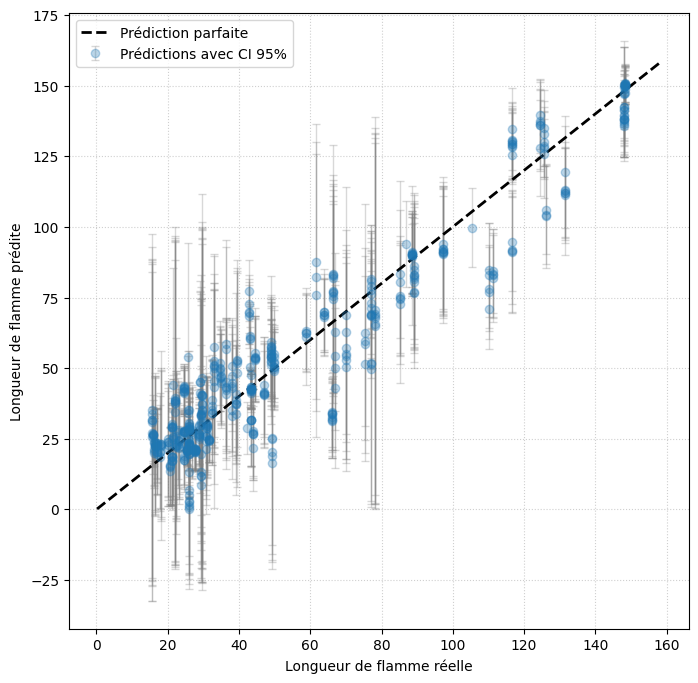

In [11]:
# VALIDATION DU MODèLE : VALIDATION SHUFFLE SPLIT + ESTIMATION DES INCERTITUDES

n_modes = 8
n_splits = 50

ss = ShuffleSplit(n_splits=n_splits, test_size=0.1, random_state=42)

all_FL_test = []
all_FL_pred = []
all_lower_bound = []
all_upper_bound = []

print(f"--- Lancement du Shuffle Split (n={n_splits}) ---")

for split_idx, (train_idx, test_idx) in enumerate(ss.split(X1)):
    if (split_idx + 1) % 5 == 0 or split_idx == 0:
        print(f"Traitement du split {split_idx + 1} / {n_splits} ...")
    
    X1_tr, X1_te = X1[train_idx], X1[test_idx]
    imgs_tr, imgs_te = imgs[train_idx], imgs[test_idx]
    FL_tr, FL_te = FL_array[train_idx], FL_array[test_idx]
    sc = StandardScaler()
    X1_tr_s = sc.fit_transform(X1_tr)
    X1_te_s = sc.transform(X1_te)
    
    # Entraînement PLS
    pls_cv = PLSRegression(n_components=n_modes)
    pls_cv.fit(imgs_tr, FL_tr)
    y_tr = pls_cv.x_scores_
    
    # Entraînement GPRs 
    gpr_models = []
    for k in range(n_modes):
        gpr_k = clone(Best_GPR_global[k])
        gpr_k.fit(X1_tr_s, y_tr[:, k])
        gpr_models.append(gpr_k)
        
    # Prédiction des modes avec incertitude
    n_test = X1_te_s.shape[0]
    y_pred_mean = np.zeros((n_test, n_modes))
    y_pred_std = np.zeros((n_test, n_modes))
    
    for k in range(n_modes):
        mean, std = gpr_models[k].predict(X1_te_s, return_std=True)
        y_pred_mean[:, k] = mean
        y_pred_std[:, k] = std
        
    # Calcul Analytique des Intervalles de Confiance
    img_mean = pls_cv.inverse_transform(y_pred_mean)
    FL_pr_mean = pls_cv.predict(img_mean).ravel()
    
    dummy_scores = np.eye(n_modes)
    baseline = pls_cv.predict(pls_cv.inverse_transform(np.zeros((1, n_modes)))).ravel()
    effective_weights = pls_cv.predict(pls_cv.inverse_transform(dummy_scores)).ravel() - baseline
    
    FL_variance = np.sum((effective_weights ** 2) * (y_pred_std ** 2), axis=1)
    FL_std = np.sqrt(FL_variance)
    
    lower_bound = FL_pr_mean - 1.96 * FL_std
    upper_bound = FL_pr_mean + 1.96 * FL_std
    
    all_FL_test.extend(FL_te.ravel())
    all_FL_pred.extend(FL_pr_mean)
    all_lower_bound.extend(lower_bound)
    all_upper_bound.extend(upper_bound)
    
# --- CALCUL DES MÉTRIQUES GLOBALES ---
all_FL_test = np.array(all_FL_test)
all_FL_pred = np.array(all_FL_pred)
all_lower_bound = np.array(all_lower_bound)
all_upper_bound = np.array(all_upper_bound)

in_ci_mask = (all_FL_test >= all_lower_bound) & (all_FL_test <= all_upper_bound)
coverage_95 = in_ci_mask.mean() * 100

ci_width_mean = np.mean(all_upper_bound - all_lower_bound)
r2 = r2_score(all_FL_test, all_FL_pred)
rmse = root_mean_squared_error(all_FL_test, all_FL_pred)

print(f"\n=== RÉSULTATS FINAUX (Shuffle Split n={n_splits}) ===")
print(f"R² global                 : {r2:.3f}")
print(f"RMSE global               : {rmse:.3f}")
print(f"Prédictions dans le CI 95% : {coverage_95:.1f} %")
print(f"Largeur moyenne du CI 95%  : {ci_width_mean:.3f}")

# --- VISUALISATION ---
plt.figure(figsize=(8, 8))

yerr_lower = all_FL_pred - all_lower_bound
yerr_upper = all_upper_bound - all_FL_pred

plt.errorbar(all_FL_test, all_FL_pred, yerr=[yerr_lower, yerr_upper], 
             fmt='o', ecolor='gray', elinewidth=1, capsize=3, alpha=0.3, # Alpha réduit à 0.3 car il y a 450 points à tracer !
             label='Prédictions avec CI 95%')

max_val = max(np.max(all_FL_test), np.max(all_FL_pred)) * 1.05
min_val = min(np.min(all_FL_test), np.min(all_FL_pred)) * 0.95
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Prédiction parfaite')
plt.xlabel('Longueur de flamme réelle')
plt.ylabel('Longueur de flamme prédite')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Testing point 5 / 93 ...
Testing point 10 / 93 ...
Testing point 15 / 93 ...
Testing point 20 / 93 ...
Testing point 25 / 93 ...
Testing point 30 / 93 ...
Testing point 35 / 93 ...
Testing point 40 / 93 ...
Testing point 45 / 93 ...
Testing point 50 / 93 ...
Testing point 55 / 93 ...
Testing point 60 / 93 ...
Testing point 65 / 93 ...
Testing point 70 / 93 ...
Testing point 75 / 93 ...
Testing point 80 / 93 ...
Testing point 85 / 93 ...
Testing point 90 / 93 ...


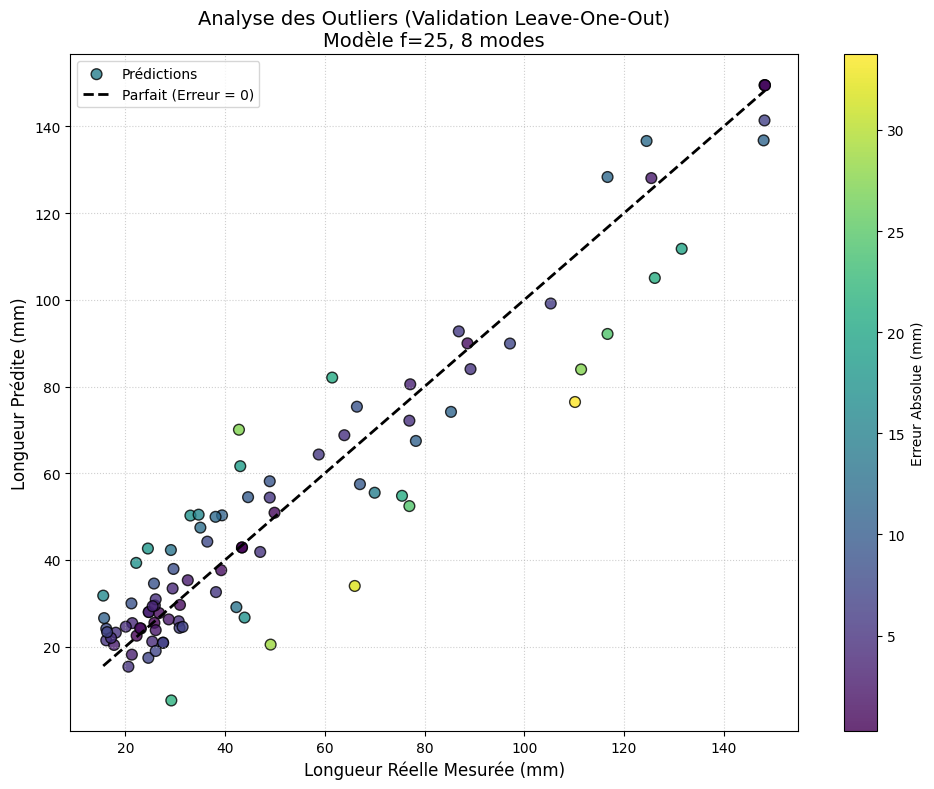

-------- Results --------


ValueError: Input contains NaN.

In [ ]:
# IDENTIFICATION DES OUTLIERS
# On effectue une validation Leave One Out (LOO), pour identifier précisement les outliers. 
# On se penche sur chaque point qui s'écarte un peu trop de la prédiction parfaite.

loo = LeaveOneOut()
n_modes = 8 

FL_test = []
FL_pred = []
err_abs = []
count = 1

for train_idx, test_idx in loo.split(X1) :
    if count % 5 == 0 : print(f"Testing point {count} / {len(FL_list) - 1} ...")
    X1_tr, X1_te = X1[train_idx], X1[test_idx]
    imgs_tr, imgs_te = imgs[train_idx], imgs[test_idx]
    FL_tr, FL_te = FL_array[train_idx], FL_array[test_idx]
    FL_tr_log = np.power(FL_tr,1/0.9)
    mean_img = np.mean(imgs_tr, axis=0).reshape((1,-1))
    imgs_tr = imgs_tr - mean_img
    
    sc = StandardScaler()
    X1_tr_s = sc.fit_transform(X1_tr)
    X1_te_s = sc.transform(X1_te)
    
    pls_loo = PLSRegression(n_components=n_modes)
    pls_loo.fit(imgs_tr, FL_tr_log)
    y_tr = pls_loo.x_scores_
    
    y_pred = np.zeros((1, n_modes))
    
    gpr_models = []
    for k in range(n_modes):
        gpr_k = clone(Best_GPR_global[k])
        gpr_k.fit(X1_tr_s, y_tr[:, k])
        y_pred[:,k] = gpr_k.predict(X1_te_s)  
        
    img_pred = pls_loo.inverse_transform(y_pred)
    FL_pred_loo = np.power(pls_loo.predict(img_pred + mean_img).ravel()[0],0.9)
    FL_test_loo = FL_te.ravel()[0]
    
    FL_test.append(FL_test_loo)
    FL_pred.append(FL_pred_loo)
    err_abs.append(abs(FL_test_loo - FL_pred_loo))
    
    count += 1

FL_test = np.array(FL_test)
FL_pred = np.array(FL_pred)
err_abs = np.array(err_abs)


seuil_outliers = 2 * np.sqrt(np.mean(err_abs**2))
ind_outliers = np.where(err_abs > seuil_outliers)[0] 
    
plt.figure(figsize=(10, 8))

plt.scatter(FL_test, FL_pred, c=err_abs, cmap='viridis', 
            s=60, alpha=0.8, edgecolors='k', label='Prédictions')

for idx in ind_outliers:
    plt.scatter(FL_test[idx], FL_pred[idx], facecolors='none', 
                edgecolors='red', s=150, linewidth=2)
    
    plt.annotate(f"Img #{idx}", (FL_test[idx], FL_pred[idx]), 
                 xytext=(10, 10), textcoords='offset points', color='red', weight='bold')

# Ligne parfaite
min_val, max_val = min(FL_test), max(FL_test)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Parfait (Erreur = 0)')

plt.colorbar(label="Erreur Absolue (mm)")
plt.title("Analyse des Outliers (Validation Leave-One-Out)\nModèle f=25, 8 modes", fontsize=14)
plt.xlabel("Longueur Réelle Mesurée (mm)", fontsize=12)
plt.ylabel("Longueur Prédite (mm)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()    

print("-------- Results --------")
(np.array(FL_list) / X_df['d1'].values).reshape(-1, 1)
print(f"R² = {r2_score(FL_test[~np.isnan(FL_pred)] / X_df['d1'].values[~np.isnan(FL_pred)]/1000,FL_pred[~np.isnan(FL_pred)] / X_df['d1'].values[~np.isnan(FL_pred)]/1000)}")
print(f"RMSE = {root_mean_squared_error(FL_test[~np.isnan(FL_pred)]  / X_df['d1'].values[~np.isnan(FL_pred)]/1000,FL_pred[~np.isnan(FL_pred)]  / X_df['d1'].values[~np.isnan(FL_pred)] / 1000)} mm")
print(f"Erreur absolue moyenne {np.mean(abs(FL_pred[~np.isnan(FL_pred)]-FL_test[~np.isnan(FL_pred)])/FL_test[~np.isnan(FL_pred)])*100} %")